#1.mpg 데이터셋을 이용한 데이터 분석

 Seaborn에서 제공하는 데이터셋인 mpg 데이터셋을 이용하여 분석

mpg 데이터셋은 1970~80년대 자동차의 연비와 성능 정보를 담고 있는 데이터

자동차의 연비, 사양, 무게, 가속력, 제조년도 및 제조국 정보가 포함

#2.데이터셋 설명

mpg.csv
- mpg : 연비, 마일 당 갤런(Miles per Gallon)
- cylinders : 실린더 수
- displacement : 배기량
- horsepower : 마력
- weight : 무게
- acceleration : 가속력
- model_year : 출시연도
- origin : 제조국
- name : 자동차 이름

#3.가지 분석 실행 해 보기

1. 연비에 영향을 미치는 요인은 무엇일까?
2. 연도별 자동차의 성능은 어떻게 변화하였을까?
3. 제조국과 브랜드에 따른 자동차의 특성은 어떻게 다를까?

##(1) 데이터 로드

In [ ]:
#seaborn에서 데이터 불러오기

In [ ]:
# 데이터 상위 5개 나열해 보기  : head() 활용

In [ ]:
# 데이터 정보  info() 활용

In [ ]:
# 질문
# horsepower의 데이터 타입은 무엇인가요?

#4.EDA(탐색적데이터분석)

In [ ]:
# 데이터의 기초 통계량을 확인하세요.describe() 활용

In [ ]:
# 질문
# 제조년도의 중앙값은 얼마인가요?  median()활용

In [ ]:
# 가장 무거운 차량을 확인하세요. max()  활용

In [ ]:
# 가장 무거운 차량의 이름은 무엇인가요? display() 활용

In [ ]:
# 데이터셋에 있는 제조국들을 확인하세요. unique() 활용

#5.결측치 처리

In [ ]:
# 결측값을 확인하세요. isna().sum()  활용

In [ ]:
# 결측값이 있는 컬럼은 어느 컬럼인가요? notna().sum()  활용

In [ ]:
# 어떤 방법으로 결측값을 처리하는게 좋을까요?

#####--> horsepower의 결측값을 중앙값으로 넣어준다

df["horsepower"].fillna(df["horsepower"].median(), inplace=True)
#df["horsepower"] = df["horsepower"].astype("float64")

In [ ]:
  # 중앙값이 93.5가 결측값이 넣어졌는지 확인해본다. head() 활용

#6.이상치 처리

In [ ]:
# 어떤 방법을 이용해 이상치를 제거할 것인가요?

In [ ]:
# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
#axes = axes.flatten()  # 2D → 1D 배열로 변경

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 남은 subplot은 숨기기 :사용하지 않는 빈 그래프 공간을 지우는 명령어
for j in range(len(numeric_cols), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [ ]:
# 질문
# 정규분포의 형태를 띄는 컬럼은 어느 것이 있나요?

<Axes: >

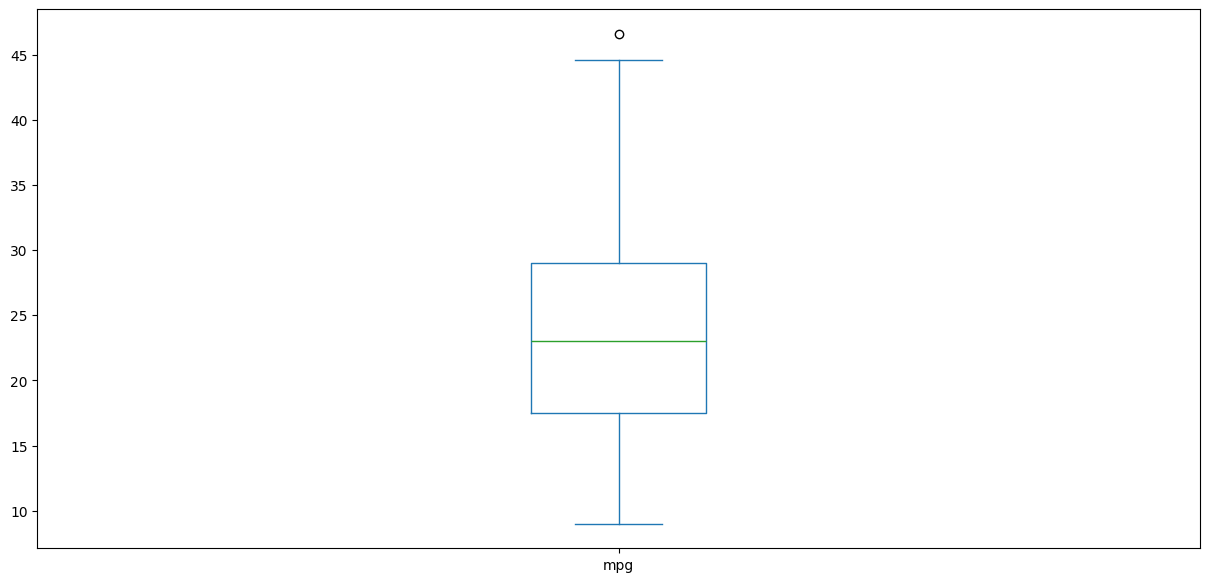

In [ ]:
# 히스토그램을 확인한 것과 동일하게 박스 플롯으로 시각화하세요.
#df["acceleration"].plot(kind="box", figsize=(15, 7))             # asseleration 을 박스플롯으로 나타내는 코딩
df["mpg"].plot(kind="box", figsize=(15, 7))                       # mpg를 박스플롯으로 나타내는 코딩
#df["horsepower"].plot(kind="box", figsize=(10, 6))               # horsepower를 박스플롯으로 나타내는 코딩

###이상치 제거: 이상치가 존재하는 컬럼은 mpg, horsepower, acceleration--> 해당 컬럼의 이상치를 제거

In [ ]:
cols = ["mpg", "horsepower", "acceleration"]

# 이상치를 제거하세요.

horsepower IRQ 알아보기

In [ ]:
# IQR 기반의 이상치 제거 함수를 만들어주세요.

# horsepower 데이터의 중앙 25%~75%범위를 알아본다
weight=1.5
IQR = df["horsepower"].describe()["75%"] -df["horsepower"].describe()["25%"]
print(IQR)

49.0


In [ ]:
# horsepower 의 upper_bound 198.5이상의 값은 모두 이상치로 간주한다
# lower_bound  찾기
# upper_bound  찾기
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

In [ ]:
# horsepower 198.5 이상의 이상치를 제거한 후 box 그림   ,
# 원본 데이터 보존을 위해 복사하여 사용

df1=df.copy()
df1= df1[df1["horsepower"]<=upper_bound]
df1["horsepower"].plot(kind="box")

mpg IRQ 범위 알아보기

In [ ]:
# mpg 데이터의   25%~75%범위를 알아본다
weight=1.5
IQR_mpg = df["mpg"].describe()["75%"] - df["mpg"].describe()["25%"]
print(IQR_mpg)

11.5


In [ ]:
# mpg 데이터의 중앙 25%~75%  범위를 정확한 수로 확인해 본다
lower_bound = df["mpg"].describe()["25%"] - weight * IQR_mpg
upper_bound = df["mpg"].describe()["75%"] + weight * IQR_mpg
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

lower_bound: 0.25
upper_bound: 46.25


In [ ]:
#  mpg 데이터의 upper_bound 46.25 이상의 이상치를 제거한 후 box 그림
#  원본 데이터 보존을 위해 복사하여 사용

df1=df.copy()
df1= df1[df1["mpg"]<=upper_bound]
df1["mpg"].plot(kind="box")

In [ ]:
cols = ["mpg", "horsepower", "acceleration"]

# IQR 기반의 이상치 제거 함수를 만들어주세요.
def remove_outliers_iqr(df_in, col_name):
    Q1 = df_in[col_name].quantile(0.25)
    Q3 = df_in[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_out = df_in[(df_in[col_name] >= lower_bound) & (df_in[col_name] <= upper_bound)]
    return df_out

# 원본 데이터 복사
df_cleaned = df.copy()

# 이상치 제거 전 데이터프레임의 행 수 확인
initial_rows = df_cleaned.shape[0]
print(f"Initial number of rows: {initial_rows}")

# 각 컬럼에 대해 이상치 제거 적용
for col in cols:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)

# 이상치 제거 후 데이터프레임의 행 수 확인
final_rows = df_cleaned.shape[0]
print(f"Number of rows after outlier removal: {final_rows}")

# 제거된 행의 수 계산
removed_rows = initial_rows - final_rows
print(f"Number of rows removed: {removed_rows}")

Initial number of rows: 398
Number of rows after outlier removal: 378
Number of rows removed: 20


총 20개의 데이터가 삭제된 것을 확인할 수 있습니다.

#7.연비에 영향을 미치는 요인은 무엇일까?

어떤 요소들이 연비를 상승시키는지 확인해볼까요?

In [ ]:
# 퀴즈 블럭

# 질문
# 어떤 방법을 통해 확인할 수 있을까요?

# 답변
# 상관계수 확인 등

상관관계 해석 기준

- 0.7 이상: 강한 양의 상관관계 – 두 변수 모두 함께 증가하는 경향이 뚜렷함
- 0.3 ~ 0.7: 중간 정도의 양의 상관관계 – 서로 일정 부분 영향을 주며 함께 증가
- 0 ~ 0.3: 약한 양의 상관관계 – 거의 영향이 없거나 미미함
- 음수: 음의 상관관계 – 한 변수가 증가할 때 다른 변수는 감소하는 경향

In [ ]:
corr = df.corr(numeric_only=True)
corr

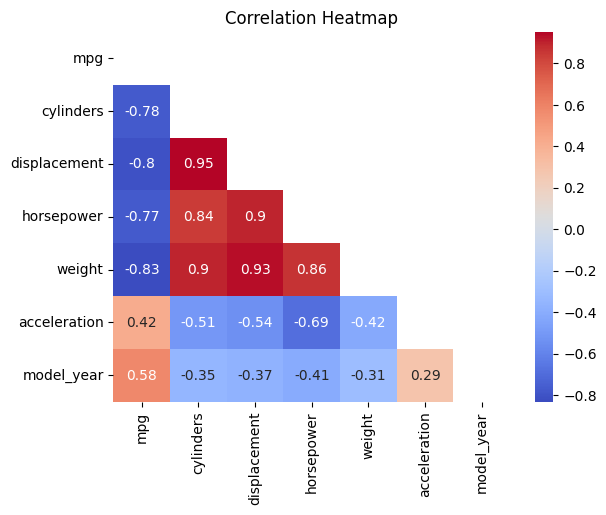

In [ ]:
mask = np.triu(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm", mask=mask)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# 퀴즈 블럭

# 질문
# weight와 displacement간의 상관계수는 몇인가요? 그리고 이것은 무엇을 의미하나요?

# 답변
# 0.94, 양의 상관관계를 가지며 weight 즉, 무게가 증가할수록 disaplacement 배기량이 증가한다.

Weight와 MPG의 상관계수: -0.8317409332443344


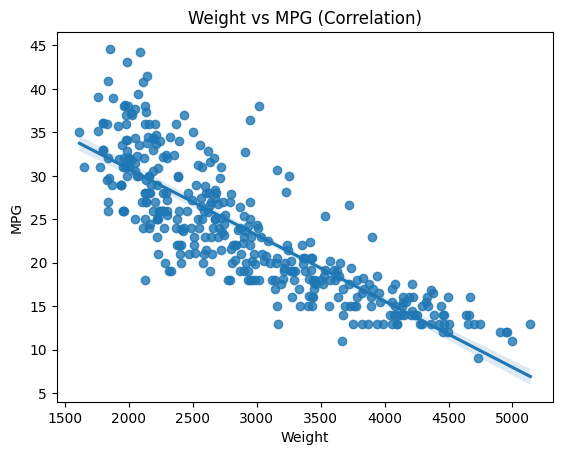

In [ ]:
# weight와 mpg의 상관관계를 확인해보세요.

print(f"Weight와 MPG의 상관계수: {corr.loc['weight', 'mpg']}")
sns.regplot(x='weight', y='mpg', data=df_cleaned)
plt.title('Weight vs MPG (Correlation)')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

In [ ]:
# 질문
# weight와 mpg는 어떤 상관관계를 가지고 있나요?

# 답변
# 음의 상관관계, 자동차의 무게가 무거울수록 연비가 낮아진다.

HorsePower와 MPG의 상관계수: -0.7734532045742144


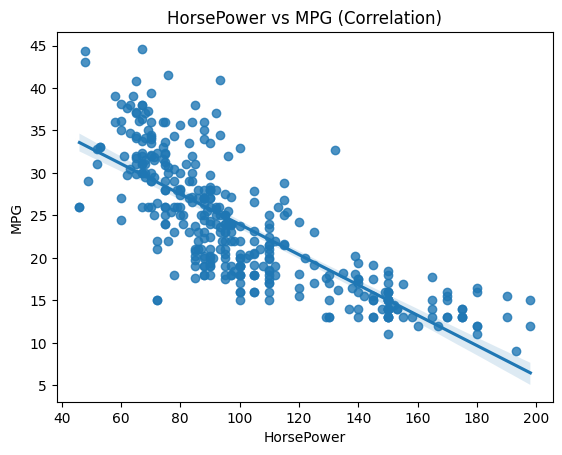

In [ ]:
# horsepower와 mpg의 상관관계를 확인해보세요.
print(f"HorsePower와 MPG의 상관계수: {corr.loc['horsepower', 'mpg']}")
sns.regplot(x='horsepower', y='mpg', data=df_cleaned)
plt.title('HorsePower vs MPG (Correlation)')
plt.xlabel('HorsePower')
plt.ylabel('MPG')
plt.show()

In [ ]:
# 질문
# horsepower와 mpg는 어떤 상관관계를 가지고 있나요?

# 답변
# 음의 상관관계, 마력이 높을수록 연비가 낮아진다.

Model Year와 MPG의 상관계수: 0.5792671330833092


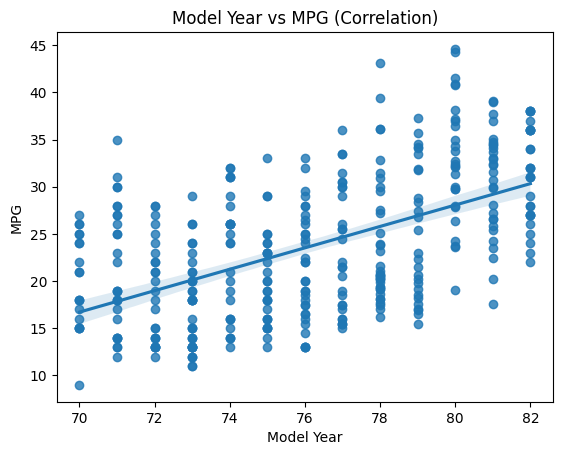

In [ ]:
# model_year와 mpg의 상관관계를 확인해보세요.

print(f"Model Year와 MPG의 상관계수: {corr.loc['model_year', 'mpg']}")
sns.regplot(x='model_year', y='mpg', data=df_cleaned)
plt.title('Model Year vs MPG (Correlation)')
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.show()

In [ ]:
# 질문
# model_year와 mpg는 어떤 상관관계를 가지고 있나요?

# 답변
# 양의 상관관계, 최신 연식이 될 수록 연비가 좋아진다.

자동차 연비는 무게(weight), 마력(horsepower), 배기량(displacement)과 음의 상관관계를 가지며, 출시 연도(model_year)가 높을수록 연비는 증가하는 경향을 보입니다.

즉, 무게가 가볍고, 배기량과 마력이 낮으며, 최신에 출시된 자동차일수록 연비가 좋다고 해석할 수 있습니다.

#8.연도별 자동차의 성능은 어떻게 변화하였을까?

In [ ]:
# 질문
# 성능이라고 부를 수 있을만한 컬럼은 무엇인가요?

# 답변
# model_year를 제외한 모든 수치형 컬럼들이 해당

In [ ]:
# 연도 별 추세를 확인할 수 있는 차트 그리기 (hint : lineplot을 이용하면 손쉽게 추세를 확인 가능)

# 'model_year'를 기준으로 그룹화하고 각 수치형 컬럼의 평균 계산
year_avg = df_cleaned.groupby('model_year')[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].mean()

# 시각화
plt.figure(figsize=(10, 6))

# MPG 추세
plt.subplot(3, 2, 1)
sns.lineplot(x=year_avg.index, y='mpg', data=year_avg)
plt.title('Average MPG by Model Year')

# Cylinders 추세
plt.subplot(3, 2, 2)
sns.lineplot(x=year_avg.index, y='cylinders', data=year_avg)
plt.title('Average Cylinders by Model Year')

# Displacement 추세
plt.subplot(3, 2, 3)
sns.lineplot(x=year_avg.index, y='displacement', data=year_avg)
plt.title('Average Displacement by Model Year')

# Horsepower 추세
plt.subplot(3, 2, 4)
sns.lineplot(x=year_avg.index, y='horsepower', data=year_avg)
plt.title('Average Horsepower by Model Year')

# Weight 추세
plt.subplot(3, 2, 5)
sns.lineplot(x=year_avg.index, y='weight', data=year_avg)
plt.title('Average Weight by Model Year')

# Acceleration 추세
plt.subplot(3, 2, 6 )
sns.lineplot(x=year_avg.index, y='acceleration', data=year_avg)
plt.title('Average Acceleration by Model Year')

plt.tight_layout()
plt.show()

In [ ]:
# 연도 별 변화 추이를 수로도 확인해볼까요? (hint : groupby를 이용해보세요.)

# 'model_year'를 기준으로 그룹화하고 각 수치형 컬럼의 평균 계산
year_avg = df_cleaned.groupby('model_year')[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].mean()
display(year_avg.round(2))

In [ ]:
# 질문
# 연도가 지날수록 어떻게 변화하고 있나요?

# 답변
# 연도가 지날수록 다음과 같은 경향이 있다고 추측가능
# 연비, 가속력은 상승 → 차량 성능 향상 및 연비 개선 기술 발달
# 배기량, 마력, 무게는 하락 → 에너지 효율성과 환경 규제를 고려한 차량 경량화 및 소형화 경향

#9.제조국과 브랜드에 따른 자동차의 특성은 어떻게 다를까?

In [ ]:
# 각 제조국 별 특성을 확인하세요.
Origin_avg = df_cleaned.groupby('origin')[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']].mean()
display(Origin_avg.round(2))

#10.제조국들은 각각 어떤 특성을 가지고 있나요?

- 미국 (USA)
    - 평균 연비: 20.4 mpg로 가장 낮음
    - 실린더 수와 배기량, 마력이 모두 가장 높으며, 차량 무게도 평균 3316lbs로 가장 무겁습니다
    - 출력과 크기를 중시하는 차량 설계가 특징입니다.

- 일본 (Japan)
    - 평균 연비: 30.2 mpg로 가장 높음
    - 배기량과 마력, 무게가 모두 가장 낮으며, 실린더 수도 작음
    - 경량화와 연비 효율을 우선한 설계가 두드러집니다.

- 유럽 (Europe)
    - 평균 연비: 27.5 mpg, 크기·출력도 중간값 유지
    - 미국과 일본의 중간에 위치한 균형 잡힌 차량 특성을 보임
    - 다양한 용도에 적합한 보편적인 차량 구성을 보입니다.

In [ ]:
# 브랜드를 새로운 특성으로 만들어주세요. (hint: name의 가장 앞단어는 브랜드인 것 같아요.)
df_cleaned['brand'] = df_cleaned['name'].apply(lambda x: x.split(' ')[0])
display(df_cleaned.head())

In [ ]:
# 질문
# 데이터셋에 가장 많은 브랜드는 어디인가요?

most_common_brand = df_cleaned['brand'].value_counts().idxmax()
most_common_brand_count = df_cleaned['brand'].value_counts().max()
print(f"데이터셋에서 가장 많은 브랜드는 '{most_common_brand}' 이고, 총 {most_common_brand_count}개 입니다.")

데이터셋에서 가장 많은 브랜드는 'ford' 이고, 총 50개 입니다.


In [ ]:
# 상위 10개 브랜드가 데이터셋을 차지하는 비율은 몇 퍼센트인가요?

In [ ]:
# 상위 10개 브랜드의 비율을 계산하세요.
brand_counts = df_cleaned['brand'].value_counts()
top_10_brands_count = brand_counts.head(10).sum()
total_cars = len(df_cleaned)
percentage = (top_10_brands_count / total_cars) * 100
print(f"상위 10개 브랜드가 데이터셋을 차지하는 비율은 {percentage:.2f}% 입니다.")

상위 10개 브랜드가 데이터셋을 차지하는 비율은 70.11% 입니다.


In [ ]:
# 상위 10개 브랜드들의 특성에 대해 확인하세요.

top_10_brands = df_cleaned['brand'].value_counts().head(10).index.tolist()
df_top_10 = df_cleaned[df_cleaned['brand'].isin(top_10_brands)]

brand_characteristics = df_top_10.groupby('brand')[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']].mean()
display(brand_characteristics.round(2))

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
brand,,,,,,,
amc,18.37,6.30,245.00,111.13,3259.56,15.51,74.44
buick,20.01,6.27,248.67,124.60,3491.33,15.26,76.73
chevrolet,20.42,6.15,236.32,111.80,3280.00,15.31,75.63
datsun,31.11,4.26,103.26,83.83,2242.22,16.41,76.87
dodge,22.47,5.93,219.61,113.74,3162.70,14.50,76.78
ford,19.89,6.04,231.34,109.05,3274.94,15.41,75.60
plymouth,22.23,5.86,211.21,106.17,3167.83,15.31,75.45
pontiac,20.73,6.00,261.93,124.00,3555.86,14.70,76.07
toyota,28.37,4.24,111.32,83.44,2301.16,16.10,76.52


In [ ]:
# 질문
# 연비가 가장 안좋은 브랜드는 어디인가요?

In [ ]:
# 연비가 가장 안 좋은 브랜드는 어디인가요?
lowest_mpg_brand = brand_characteristics['mpg'].idxmin()
lowest_mpg_value = brand_characteristics['mpg'].min()
print(f"연비가 가장 안 좋은 브랜드는 '{lowest_mpg_brand}' 이고, 평균 연비는 {lowest_mpg_value:.2f} mpg 입니다.")

연비가 가장 안 좋은 브랜드는 'amc' 이고, 평균 연비는 18.37 mpg 입니다.


In [ ]:
# 차량의 크기 추측할 수 있는 지표를 만들어볼까요? (수식 : 배기량/10 * 무게/100)

df_cleaned['car_size'] = (df_cleaned['displacement'] / 10) * (df_cleaned['weight'] / 100)
display(df_cleaned.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,brand,car_size
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,chevrolet,1075.728
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,buick,1292.550
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,plymouth,1092.648
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,amc,1043.632
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,ford,1041.598


In [ ]:
# 가장 차량의 평균 크기가 큰 브랜드는 어디인가요?

# cadillac

In [ ]:
# 가장 차량의 평균 크기가 큰 브랜드는 어디인가요?
average_car_size_by_brand = df_cleaned.groupby('brand')['car_size'].mean()
largest_car_size_brand = average_car_size_by_brand.idxmax()
largest_car_size_value = average_car_size_by_brand.max()
print(f"가장 차량의 평균 크기가 큰 브랜드는 '{largest_car_size_brand}' 이고, 평균 크기는 {largest_car_size_value:.2f} 입니다.")

가장 차량의 평균 크기가 큰 브랜드는 'cadillac' 이고, 평균 크기는 1449.00 입니다.
